## Inventory Management Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
beg_inv = pd.read_csv("BegInvFINAL12312016.csv")
end_inv = pd.read_csv("EndInvFINAL12312016.csv")
purchases = pd.read_csv("PurchasesFINAL12312016.csv")
sales = pd.read_csv("SalesFINAL12312016.csv")

In [3]:
#Clean Data

beg_inv["startDate"] = pd.to_datetime(beg_inv["startDate"])
end_inv["endDate"] = pd.to_datetime(end_inv["endDate"])
sales["SalesDate"] = pd.to_datetime(sales["SalesDate"])
purchases["PayDate"] = pd.to_datetime(purchases['PayDate'])
purchases["PODate"] = pd.to_datetime(purchases['PODate'])


In [4]:
purchases_df = purchases.copy()
sales_df = sales.copy()

In [5]:
purchases_df = purchases_df[purchases_df['PayDate'].dt.year == 2016]
sales_df = sales_df[sales_df['SalesDate'].dt.year == 2016]

### Company Profits

First we can look at total purchases and total sales monthly and yearly.

Monthly Gross Profit:

In [6]:
revenue_df = sales_df.groupby(sales["SalesDate"].dt.month)['SalesDollars'].sum().reset_index()
cogs_df = purchases_df.groupby(purchases["PayDate"].dt.month)['Dollars'].sum().reset_index()

revenue_df.columns = ['Month', 'Revenue']
cogs_df.columns = ['Month', 'COGS']

profits_df = revenue_df.merge(cogs_df, on = 'Month').assign(
   Net_Profit = lambda df: df['Revenue'] - df['COGS']
).assign(
    Profit_Margin = lambda df: (df['Net_Profit']/df['Revenue'])*100
)

profits_df


,Month,Revenue,COGS,Net_Profit,Profit_Margin
0,2,28876607.23,11696464.50,17180142.73,59.495018
1,3,28988411.94,19786690.64,9201721.30,31.742757
2,4,30723734.63,20364895.69,10358838.94,33.716080
3,5,36041210.52,20548600.48,15492610.04,42.985820
4,6,39290701.46,21584530.39,17706171.07,45.064533
5,7,49696466.85,29975465.99,19721000.86,39.682903
6,8,39056166.03,32362458.98,6693707.05,17.138669
7,9,38477538.83,30863337.34,7614201.49,19.788692
8,10,36433141.73,30247620.31,6185521.42,16.977733
9,11,42312696.86,26765519.16,15547177.70,36.743528


Yearly Gross Profit:

In [88]:
gross_profit = sales_df['SalesDollars'].sum() - purchases_df['Dollars'].sum()
gross_profit.round()

175144489.0

Yearly Gross Profit Margin:

In [89]:
((gross_profit/sales['SalesDollars'].sum())*100).round()

39.0

Average Monthly Profit Margin

In [97]:
profits_df['Profit_Margin'].mean()

34.61661237041698

### A View on Profits

First we can look at net profits per month.

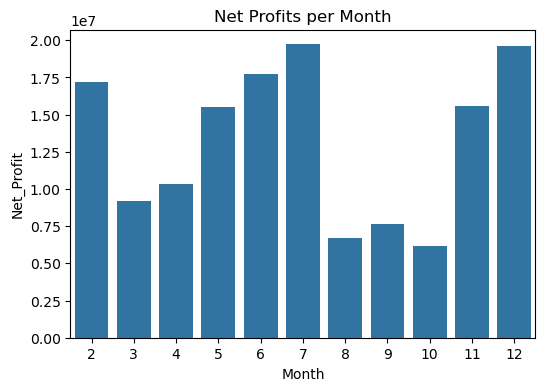

In [9]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Month', y= 'Net_Profit', data = profits_df)
plt.title("Net Profits per Month")
plt.show()

The company had no purchases made in January and relied on inventory to carry them into February thus the large profit in February. July and December has the most profit. Its possible to further investigate this by looking at cost of goods sold in February.

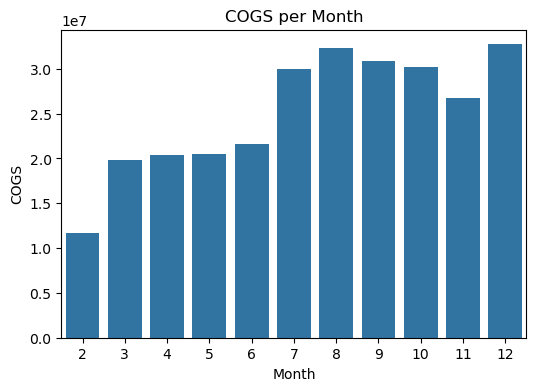

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Month', y= 'COGS', data = profits_df,)
plt.title("COGS per Month")
plt.show()

So, it can be seen that February had the lowest spending. Due to the low spending, and large net profits February must've had the highest profit margin.

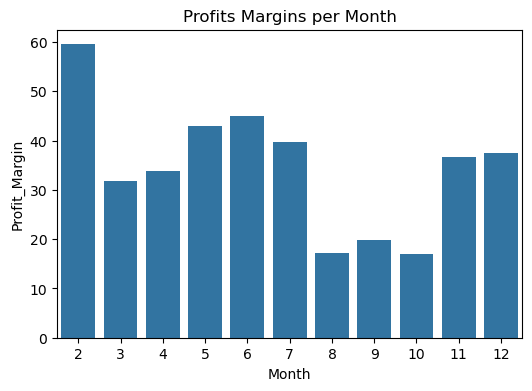

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Month', y= 'Profit_Margin', data = profits_df,)
plt.title("Profits Margins per Month")
plt.show()

## Economic Order Quantity (EOQ) Calculation

EOQ helps businesses determine the optimal quantity that meets demand while minimizing its total costs related to ordering, receiving, and holding inventory.

###  Estimate Ordering Cost (S)

We can estimate ordering cost by looking at different components that have to be factored in:  

| Component                 | Description                                                   | Example Cost |
| ------------------------- | ------------------------------------------------------------- | ------------ |
| **Admin Costs**           | Time spent placing, tracking, and approving orders            | \~\$20–50    |
| **Shipping Setup**        | Freight setup, loading/unloading fees                         | \~\$30–80    |
| **Supplier Coordination** | Quality checks, sampling, compliance (especially for alcohol) | \~\$10–40    |
| **Regulatory Handling**   | Licensing checks, bonded warehouse management                 | \~\$10–50    |
| **Flat Fees**             | Fixed vendor/order service fees (e.g. courier or customs)     | \~\$30–100   |

With this it's reasonable to set the ordering cost to 100$ since we are not provided that information from the data set.

### Estimate Holding Cost (H)

Usually calculated as a percentage of item value, often 20–30% per year.

H = Unit Cost × Holding Rate


For this application I will use 25% of unit cost

### Calculations

In [33]:
ordering_cost = 100
holding_rate = 0.25
annual_demand_quantity = sales_df.groupby('Brand')['SalesQuantity'].sum().reset_index(name = 'UnitQuantity')
annual_demand_mean_price = sales_df.groupby('Brand')['SalesPrice'].mean().round(2).reset_index(name = 'Mean Price')
annual_demand = annual_demand_quantity.merge(annual_demand_mean_price, on = 'Brand')

annual_demand['EOQ'] = np.sqrt((annual_demand['UnitQuantity']*2*ordering_cost)/(annual_demand['Mean Price']*holding_rate)).round()
annual_demand

,Brand,UnitQuantity,Mean Price,EOQ
0,58,3446,12.59,468.0
1,60,1775,10.50,368.0
2,61,312,13.99,134.0
3,62,3125,38.38,255.0
4,63,2778,40.44,234.0
...,...,...,...,...
11232,90089,159,119.99,33.0
11233,90090,15,649.99,4.0
11234,90604,76,119.99,23.0
11235,90609,83,24.99,52.0


### EOQ Can help

- Avoid over-ordering (which leads to excess inventory)

- Avoid under-ordering (which leads to stockouts)

- Minimize total cost of inventory

### Inventory Movement - Check How Much Stock 

Theoretical End Inventory = Beginning On Hand + Purchases - Sales


In [47]:
beg_inv_df = beg_inv.copy()
end_inv_df = end_inv.copy()


In [90]:
beg_onhand = beg_inv_df.groupby('Brand')['onHand'].sum().reset_index(name = 'Beginning on hand')
purchases_quant= purchases_df.groupby('Brand')['Quantity'].sum().reset_index(name = 'Purchase Quantity')
sales_quant = sales_df.groupby('Brand')['SalesQuantity'].sum().reset_index(name = 'Sale Quantity' )

theo_end_inv = beg_onhand.merge(purchases_quant, on = 'Brand').merge(sales_quant, on = 'Brand')
theo_end_inv['Theoretical End Inv'] = (theo_end_inv['Beginning on hand'] + theo_end_inv['Purchase Quantity']) - theo_end_inv['Sale Quantity']

In [45]:
theo_end_inv.sample(10)

,Brand,Beginning on hand,Purchase Quantity,Sale Quantity,Theoretical End Inv
1513,4018,229,782,831,180
3761,17361,82,191,225,48
68,262,3,3,4,2
6078,31524,399,689,867,221
6061,31384,506,1281,1462,325
4671,21435,14,8,22,0
6786,41558,12,132,123,21
2924,11456,726,1583,1856,453
4170,19459,9,2,2,9
3990,18744,36,2162,1134,1064


In [49]:
real_end_inv = end_inv_df.groupby('Brand')['onHand'].sum().reset_index(name = 'Real End Inventory')

end_inventory_compare = theo_end_inv.merge(real_end_inv, on = 'Brand')


,Brand,Beginning on hand,Purchase Quantity,Sale Quantity,Theoretical End Inv,Real End Inventory
0,58,281,3059,3446,-106,385
1,60,288,1429,1775,-58,146
2,61,12,276,312,-24,12
3,62,384,2893,3125,152,459
4,63,365,2523,2778,110,442
...,...,...,...,...,...,...
6609,90086,58,1,27,32,32
6610,90087,66,15,36,45,45
6611,90088,57,6,26,37,37
6612,90089,251,32,159,124,124


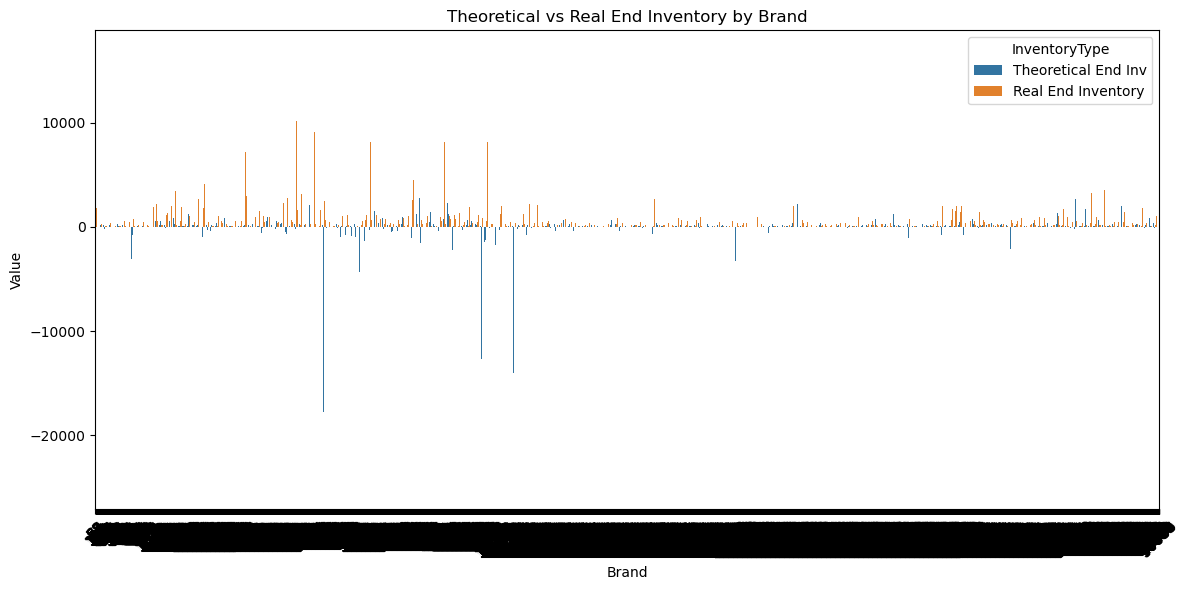

In [55]:
end_inventory_df = end_inventory_compare[['Brand','Theoretical End Inv', 'Real End Inventory']]

df_melted = end_inventory_df.melt(id_vars='Brand', value_vars=['Theoretical End Inv', 'Real End Inventory'], 
                    var_name='InventoryType', value_name='Value')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Brand', y='Value', hue='InventoryType')
plt.title("Theoretical vs Real End Inventory by Brand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This shows differences between vs real inventory and clearly there seems to be excessive amount of of real inventory suggesting that there may be overstocking.

## Identify Products with No Sales

In [68]:
# All inventory IDs sold
sold_ids = sales_df['InventoryId'].unique()

# Items in inventory never sold
unsold_items = beg_inv_df[~beg_inv_df['InventoryId'].isin(sold_ids)]
unsold_items


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
30,1_HARDERSFIELD_356,1,HARDERSFIELD,356,Carolans Irish Cr Gift Set,750mL,0,11.49,2016-01-01
41,1_HARDERSFIELD_425,1,HARDERSFIELD,425,Hennessy Paradis,750mL,1,799.99,2016-01-01
101,1_HARDERSFIELD_883,1,HARDERSFIELD,883,Patron Burdeos Anejo Tequila,750mL,2,499.99,2016-01-01
114,1_HARDERSFIELD_999,1,HARDERSFIELD,999,Jameson 18 Year Old,750mL,0,119.99,2016-01-01
115,1_HARDERSFIELD_1000,1,HARDERSFIELD,1000,Goslings Dark'n Stormy VAP,750mL,0,14.99,2016-01-01
...,...,...,...,...,...,...,...,...,...
205685,79_BALLYMENA_22759,79,BALLYMENA,22759,Meiomi Pnt Nr,375mL,0,12.99,2016-01-01
205746,79_BALLYMENA_23848,79,BALLYMENA,23848,Dom Cherrier Sancerre,750mL,0,17.99,2016-01-01
205765,79_BALLYMENA_24328,79,BALLYMENA,24328,Ch Ducru Beaucaillou 12 St J,750mL,5,154.99,2016-01-01
206171,79_BALLYMENA_36766,79,BALLYMENA,36766,Ravenswood Znfdl Lodi,750mL,0,16.99,2016-01-01


In [103]:
unsold_items_onhand = unsold_items[unsold_items['onHand'] != 0]

unsold_items_onhand['Full Price'] = unsold_items_onhand['onHand'] * unsold_items_onhand['Price']
unsold_items_onhand

/var/folders/kd/bffbp6ln4k9g3tm9l66qqbqh0000gn/T/ipykernel_1944/233384946.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unsold_items_onhand['Full Price'] = unsold_items_onhand['onHand'] * unsold_items_onhand['Price']


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate,Full Price
41,1_HARDERSFIELD_425,1,HARDERSFIELD,425,Hennessy Paradis,750mL,1,799.99,2016-01-01,799.99
101,1_HARDERSFIELD_883,1,HARDERSFIELD,883,Patron Burdeos Anejo Tequila,750mL,2,499.99,2016-01-01,999.98
147,1_HARDERSFIELD_1106,1,HARDERSFIELD,1106,Aberfeldy Single Cask,750mL,8,229.99,2016-01-01,1839.92
2664,1_HARDERSFIELD_24787,1,HARDERSFIELD,24787,Rodney Strong Chard Sonoma C,750mL,12,19.99,2016-01-01,239.88
3261,2_ASHBORNE_86,2,ASHBORNE,86,Don Julio Real Tequila,750mL,1,299.99,2016-01-01,299.99
...,...,...,...,...,...,...,...,...,...,...
205553,79_BALLYMENA_20060,79,BALLYMENA,20060,Ch Troplong Mondot 10 Brdx,750mL,12,239.99,2016-01-01,2879.88
205560,79_BALLYMENA_20162,79,BALLYMENA,20162,Hess Select Pnt Nr,750mL,12,17.99,2016-01-01,215.88
205626,79_BALLYMENA_21453,79,BALLYMENA,21453,Ch Ducru Beaucaillau St-Juli,750mL,5,153.99,2016-01-01,769.95
205765,79_BALLYMENA_24328,79,BALLYMENA,24328,Ch Ducru Beaucaillou 12 St J,750mL,5,154.99,2016-01-01,774.95


In [104]:
holding_rate = 0.25
(unsold_items_onhand['Full Price']*holding_rate).sum()

231194.6425

Almost $231,195 was lost due to holding costs for unsold items alone in 2016 if we assumed a holding rate of 0.25 of unit price.

It's also possible to look at purchases made but were never sold:

In [94]:
sold_ids = sales_df['InventoryId'].unique()

unsold_purchased_items = purchases_df[~purchases_df['InventoryId'].isin(sold_ids)]
unsold_purchased_items.sample(5)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
921929,41_LARNWICK_22943,41,22943,D'Armailhac Pauillac 05,1.5L,7153,PINE STATE TRADING CO,10505,2016-06-02,2016-06-08,2016-06-18,2016-07-31,188.43,1,188.43,2
1898060,37_PAETHSMOUTH_1189,37,1189,Mad River 3 Pack Revolution,200mL 3 Pk,9552,M S WALKER INC,12697,2016-10-20,2016-10-28,2016-11-01,2016-12-05,39.36,5,196.80,1
1411801,50_MOUNTMEND_1193,50,1193,Clynelish Cask Strgth Scotch,750mL,3960,DIAGEO NORTH AMERICA INC,11589,2016-08-10,2016-08-17,2016-08-30,2016-10-05,592.59,1,592.59,1
918660,41_LARNWICK_21470,41,21470,Ch Angelus Saint Emilion,750mL,10754,PERFECTA WINES,10524,2016-06-03,2016-06-08,2016-06-14,2016-07-29,191.50,4,766.00,2
1944907,68_SOLARIS_27031,68,27031,Opus One 2013,750mL,4425,MARTIGNETTI COMPANIES,12730,2016-10-23,2016-11-01,2016-11-11,2016-12-18,180.27,12,2163.24,2


In [95]:
unsold_purchased_items['Dollars'].sum()

947767.04

$947,767 was lost do to products purchased but was never sold, this is not factoring in order costs or holding costs.

This aligns with the graph made earlier where I suspected a overstocking issue.

In [76]:
# Purchased items that were already in inventory
len(unsold_purchased_items[unsold_purchased_items['InventoryId'].isin(beg_inv_df)])

0

## Summary

- **Yearly Gross Profit**

    - $175,144,489

- **Yearly Profit Margin**

    - 39%
    
- **Average Monthly Profit Margin**

    - 34.6%
- **Losses due to holding of unsold products**

    - $231,195

- **Losses due to purchases of unsold stock** ~ not including holding fees, and ordering costs.

    - $947,767

While the manufacturing plant's holds stable profit margins there is room for improvement by removing unsold products and stopping new orders of known poor selling stock. It is also advised to make orders based off of EOQ quantity to minimize costs related to ordering, receiving, and holding inventory.

